In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [12]:
df = pd.read_csv('student_data.csv')

x = df[['StudyHours']]
y = df['ExamScore']

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [14]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [15]:
y_pred = model.predict(x_test)

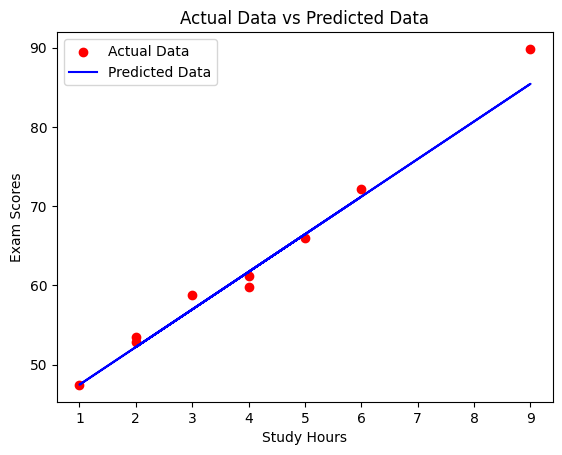

In [16]:
plt.scatter(x_test,y_test,color='red',label='Actual Data')
plt.plot(x_test,y_pred,color='blue',label='Predicted Data')
plt.title('Actual Data vs Predicted Data')
plt.xlabel('Study Hours')
plt.ylabel('Exam Scores')
plt.legend()
plt.show()

In [17]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print(f"Mean Squared Error: {mse} and R2 Score: {r2}")

Mean Squared Error: 3.2960564982818514 and R2 Score: 0.9767429918106079


In [18]:
coeff = model.coef_
inter = model.intercept_

print(f"The model has a linear regression coefficient of {coeff[0]} for StudyHours and a bias of {inter}.")

The model has a linear regression coefficient of 4.744806824538306 for StudyHours and a bias of 42.71739642112175.


In [19]:
x = sm.add_constant(x)
model = sm.OLS(y,x).fit()

In [20]:
t_stat = model.tvalues['StudyHours']
t_pvalue = model.pvalues['StudyHours']

f_stat = model.fvalue
f_pvalue = model.f_pvalue

print(f"F-Statistics: {f_stat} and T-Statistics: {t_stat}")

F-Statistics: 1203.6751355378826 and T-Statistics: 34.694021610904095


In [21]:
if f_pvalue < 0.5:
    print("Overall model and regression are statictically significant")
else:
    print("Overall model and regression are not statistically significant")

Overall model and regression are statictically significant


In [22]:
if t_pvalue < 0.5:
    print("Study Hours is the significant predictor of the Exam Scores")
else:
    print("Study Hours is not the significant predictor of the Exam Scores")

Study Hours is the significant predictor of the Exam Scores
